<a href="https://colab.research.google.com/github/Sharvesh8326/24ADI003_24BAD110_ML/blob/main/24BAD110_EXP_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Sharvesh S
Roll No: 24BAD110
Scenario 1: Multinomial Naïve Bayes

Accuracy: 0.968609865470852
Precision: 1.0
Recall: 0.7666666666666667
F1 Score: 0.8679245283018868

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



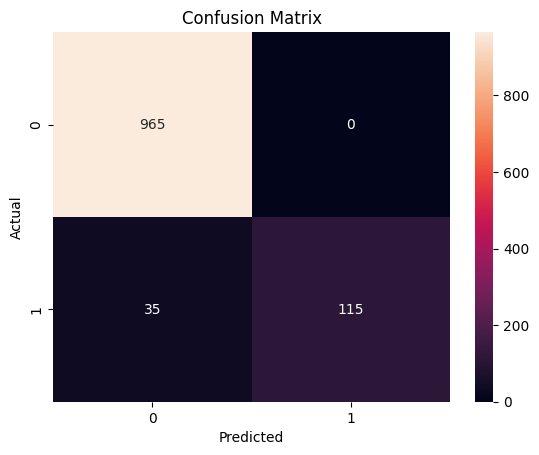


Top Words Influencing Spam:
reply
won
text
ur
stop
prize
mobile
claim
txt
free

Total Spam Words: 15806
Total Ham Words: 66523

Accuracy (alpha=0.1): 0.9766816143497757


In [ ]:
# Scenario 1: Multinomial Naïve Bayes

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 1: Multinomial Naïve Bayes\n")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Encode target
df['label'] = df['label'].map({'ham':0, 'spam':1})

# Text Cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['message'] = df['message'].apply(clean_text)

# Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['message'])
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Model (Laplace smoothing default alpha=1.0)
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance (Top Spam Words)
feature_names = vectorizer.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]
top_spam_words = np.argsort(spam_probs)[-10:]

print("\nTop Words Influencing Spam:")
for i in top_spam_words:
    print(feature_names[i])

# Word Frequency Comparison
spam_words = " ".join(df[df['label']==1]['message'])
ham_words = " ".join(df[df['label']==0]['message'])

print("\nTotal Spam Words:", len(spam_words.split()))
print("Total Ham Words:", len(ham_words.split()))

# Laplace Smoothing Impact
model_low_smooth = MultinomialNB(alpha=0.1)
model_low_smooth.fit(X_train, y_train)
print("\nAccuracy (alpha=0.1):",
      accuracy_score(y_test, model_low_smooth.predict(X_test)))

Name: Sharvesh S
Roll No: 24BAD110
Scenario 2: Gaussian Naïve Bayes

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



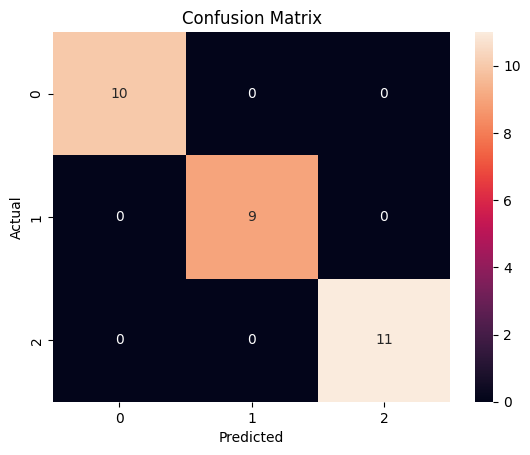


Class Probabilities (First 5 Samples):
 [[5.97322611e-090 9.95635768e-001 4.36423247e-003]
 [1.00000000e+000 4.96157683e-014 6.54921950e-021]
 [7.31861098e-290 4.92947289e-012 1.00000000e+000]
 [2.81838335e-094 9.77593560e-001 2.24064404e-002]
 [1.13876385e-105 8.70022604e-001 1.29977396e-001]]

Logistic Regression Accuracy: 1.0


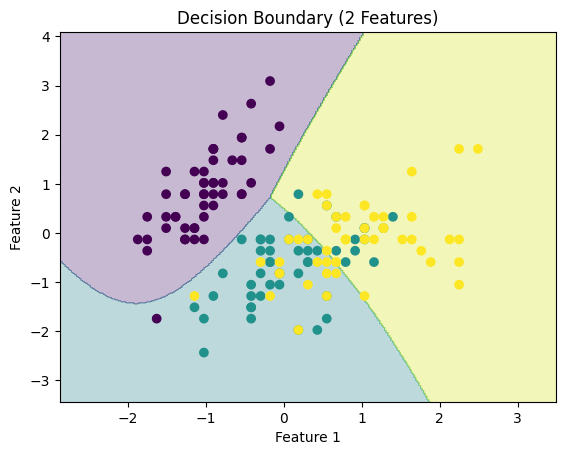

In [ ]:
# Scenario 2: Gaussian Naïve Bayes

print("Name: Sharvesh S")
print("Roll No: 24BAD110")
print("Scenario 2: Gaussian Naïve Bayes\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Load Dataset
iris = load_iris()
X = iris.data
y = iris.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Train Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Prediction
y_pred = gnb.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Class Probabilities
probs = gnb.predict_proba(X_test[:5])
print("\nClass Probabilities (First 5 Samples):\n", probs)

# Optional Comparison with Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr.predict(X_test)))

# Decision Boundary (Using first 2 features)
X2 = X_scaled[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

gnb.fit(X2_train, y2_train)

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y)
plt.title("Decision Boundary (2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()